In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Connect Flooding with WILL payload/DDoS/CSV Files/WILL_DDoS_AD_1.csv
/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Connect Flooding with WILL payload/DDoS/Pcap Files/WILL_DDoS_AD_26.pcap
/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Connect Flooding with WILL payload/DDoS/Pcap Files/WILL_DDoS_AD_7.pcap
/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Connect Flooding with WILL payload/DDoS/Pcap Files/WILL_DDoS_AD_6.pcap
/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Connect Flooding with WILL payload/DDoS/Pcap Files/WILL_DDoS_AD_20.pcap
/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Connect Flooding with WILL payload/DDoS/Pcap Files/WILL_DDoS_AD_16.pcap
/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Connect Flooding with WILL payload/DDoS/Pcap Files/WILL_DDoS_AD_5.pcap
/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Connect Flooding with WILL payload/DDoS/Pcap F

In [2]:
import pandas as pd
import numpy as np

file_path = "/kaggle/input/normal1/normal-mqtt.csv"

# Define fixed message categories
event_types = [
    'Connect Command',
    'Connect Ack',
    'Publish Message',
    'Publish Ack',
    'Publish Release',
    'Publish Complete',
    'Ping Request',
    'Ping Response'
]

window_counts = {}

chunk_size = 100000

for chunk in pd.read_csv(
        file_path,
        usecols=['Protocol','Time','Info'],
        chunksize=chunk_size):

    # Filter MQTT only
    chunk = chunk[chunk['Protocol'] == 'MQTT']

    # Convert Time safely
    chunk['Time'] = pd.to_numeric(chunk['Time'], errors='coerce')
    #chunk['window'] = (chunk['Time'] // 1).astype(int)
    window_size = 5
    chunk['window'] = (chunk['Time'] // window_size).astype(int)


    # Initialize per-window dictionary
    for w in chunk['window'].unique():
        if w not in window_counts:
            window_counts[w] = {e:0 for e in event_types}

    # Count manually using vectorized filtering
    for event in event_types:
        mask = chunk['Info'].str.contains(event, na=False)
        counts = chunk[mask].groupby('window').size()
        for w, c in counts.items():
            window_counts[w][event] += int(c)

print("Finished safely.")


Finished safely.


In [3]:
window_df = pd.DataFrame.from_dict(window_counts, orient='index').fillna(0)

print(window_df.shape)
print(window_df.head())


(3379, 8)
   Connect Command  Connect Ack  Publish Message  Publish Ack  \
2                1            1                3            0   
3                2            2                4            0   
4                6            6                4            0   
5                7            7                5            0   
6               11           11                6            0   

   Publish Release  Publish Complete  Ping Request  Ping Response  
2                4                 4             0              0  
3                6                 6             0              0  
4                4                 4             0              0  
5                6                 6             0              0  
6                9                 9             0              0  


In [4]:
probabilities = window_df.div(
    window_df.sum(axis=1), axis=0
).fillna(0)

print(probabilities.head())


   Connect Command  Connect Ack  Publish Message  Publish Ack  \
2         0.076923     0.076923         0.230769          0.0   
3         0.100000     0.100000         0.200000          0.0   
4         0.250000     0.250000         0.166667          0.0   
5         0.225806     0.225806         0.161290          0.0   
6         0.239130     0.239130         0.130435          0.0   

   Publish Release  Publish Complete  Ping Request  Ping Response  
2         0.307692          0.307692           0.0            0.0  
3         0.300000          0.300000           0.0            0.0  
4         0.166667          0.166667           0.0            0.0  
5         0.193548          0.193548           0.0            0.0  
6         0.195652          0.195652           0.0            0.0  


In [5]:
baseline_profile = probabilities.mean()

print("Baseline Profile:")
print(baseline_profile)


Baseline Profile:
Connect Command     0.242483
Connect Ack         0.242481
Publish Message     0.187477
Publish Ack         0.150149
Publish Release     0.089332
Publish Complete    0.087237
Ping Request        0.000420
Ping Response       0.000420
dtype: float64


In [6]:
mid = len(probabilities) // 2

p1 = probabilities.iloc[:mid].mean()
p2 = probabilities.iloc[mid:].mean()

import numpy as np

def hellinger(p, q):
    return np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2)) / np.sqrt(2)

print("Hellinger distance between halves:",
      hellinger(p1.values, p2.values))


Hellinger distance between halves: 0.0074024206866699915


In [7]:
normal_distances = probabilities.apply(
    lambda row: hellinger(row.values, baseline_profile.values),
    axis=1
)

print(normal_distances.describe())


count    3379.000000
mean        0.062283
std         0.045869
min         0.020817
25%         0.034643
50%         0.049478
75%         0.072628
max         0.435000
dtype: float64


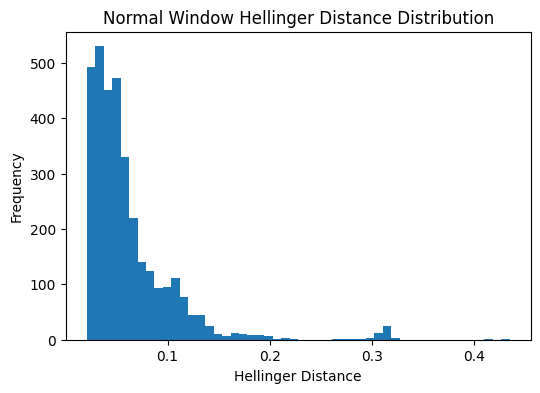

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(normal_distances, bins=50)
plt.title("Normal Window Hellinger Distance Distribution")
plt.xlabel("Hellinger Distance")
plt.ylabel("Frequency")
plt.show()


In [9]:
print(normal_distances.describe())


count    3379.000000
mean        0.062283
std         0.045869
min         0.020817
25%         0.034643
50%         0.049478
75%         0.072628
max         0.435000
dtype: float64


In [10]:
threshold = normal_distances.mean() + 3 * normal_distances.std()
print("Detection Threshold:", threshold)


Detection Threshold: 0.19988876627533764


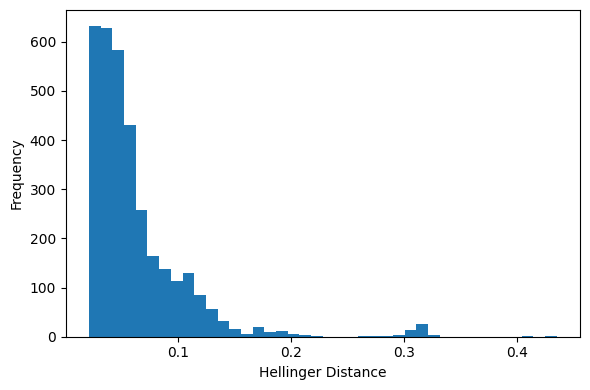

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(normal_distances, bins=40)
#plt.title("Normal Window Hellinger Distance Distribution")
plt.xlabel("Hellinger Distance")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("normal_hellinger_distribution.png", dpi=300)
plt.savefig("normal_hellinger_distribution.eps", format='eps')

plt.show()


In [12]:
import pandas as pd
import numpy as np

attack_path = "/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Basic Connect Flooding/DDoS/CSV Files/BF1_DDoS_AD_1.csv"
df_test = pd.read_csv(attack_path, nrows=5)
print(df_test.columns)
print(df_test.head())




Index(['No.', 'Message Type', 'QoS Level', 'QoS Level.1', 'Requested QoS',
       'Epoch Time', 'Protocol', 'Source', 'Frame length on the wire',
       'Time delta from previous displayed frame',
       'Time since reference or first frame', 'Frame length on the wire.1',
       'Stream index', 'iRTT', 'Time since first frame in this TCP stream',
       'TCP Segment Len', 'Calculated window size', 'Syn', 'Reset',
       'Acknowledgment', 'Clean Session Flag', 'Keep Alive',
       'User Name Length', 'Password Length', 'Retain', 'Clean Session Flag.1',
       'Will Retain', 'Will Flag', 'Will Message Length', 'Will Topic Length',
       'Topic Length', 'Msg Len', 'Info'],
      dtype='object')
   No.     Message Type  QoS Level                              QoS Level.1  \
0    1              NaN        NaN                                      NaN   
1    3              NaN        NaN                                      NaN   
2    4  Connect Command        NaN  At most once delivery (Fi

In [13]:
#Attack1: DDOD-Basic connect flooding
import pandas as pd
import numpy as np

attack1_path = "/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Basic Connect Flooding/DDoS/CSV Files/BF1_DDoS_AD_1.csv"

event_types = [
    'Connect Command',
    'Connect Ack',
    'Publish Message',
    'Publish Ack',
    'Publish Release',
    'Publish Complete',
    'Ping Request',
    'Ping Response'
]

window_size = 5
chunk_size = 100000

attack1_window_counts = {}

for chunk in pd.read_csv(
        attack1_path,
        usecols=['Protocol','Epoch Time','Message Type'],
        chunksize=chunk_size):

    # Keep only MQTT rows
    chunk = chunk[chunk['Protocol'] == 'MQTT']

    # Remove NaN message types
    chunk = chunk[chunk['Message Type'].notna()]

    # Convert Epoch Time
    chunk['Time'] = pd.to_numeric(chunk['Epoch Time'], errors='coerce')

    # Normalize time to start at 0 (important!)
    chunk['Time'] = chunk['Time'] - chunk['Time'].min()

    # Create 5-second windows
    chunk['window'] = (chunk['Time'] // window_size).astype(int)

    # Initialize windows
    for w in chunk['window'].unique():
        if w not in attack1_window_counts:
            attack1_window_counts[w] = {e:0 for e in event_types}

    # Count events
    grouped = chunk.groupby(['window','Message Type']).size()

    for (w, msg), count in grouped.items():
        if msg in event_types:
            attack1_window_counts[w][msg] += int(count)

print("Attack processing finished.")


Attack processing finished.


In [14]:
attack1_df = pd.DataFrame.from_dict(
    attack1_window_counts, orient='index'
).fillna(0)

print("Attack windows:", attack1_df.shape)
print(attack1_df.head())


Attack windows: (58, 8)
   Connect Command  Connect Ack  Publish Message  Publish Ack  \
0             1177            0               44           51   
1             1200            0               47           59   
2             1226            0               51           61   
3             1407            0               45           54   
4             1247            0               42           63   

   Publish Release  Publish Complete  Ping Request  Ping Response  
0               37                34             1              0  
1               21                28             1              0  
2               23                33             0              0  
3               18                29             0              0  
4               19                28             0              0  


In [15]:
attack1_prob = attack1_df.div(
    attack1_df.sum(axis=1), axis=0
).fillna(0)


In [16]:
def hellinger(p, q):
    return np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2)) / np.sqrt(2)

attack1_distances = attack1_prob.apply(
    lambda row: hellinger(row.values, baseline_profile.values),
    axis=1
)

print(attack1_distances.describe())


count    58.000000
mean      0.553159
std       0.039443
min       0.469413
25%       0.537322
50%       0.553946
75%       0.575437
max       0.712443
dtype: float64


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


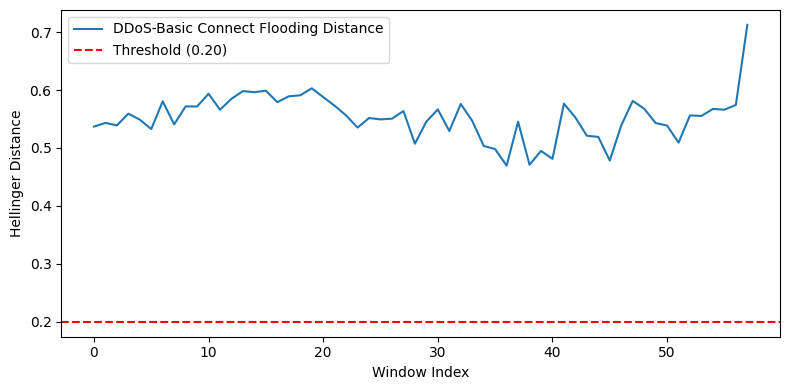

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(attack1_distances.values, label="DDoS-Basic Connect Flooding Distance")
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold (0.20)")
#plt.title("Basic Connect Flooding Detection")
plt.xlabel("Window Index")
plt.ylabel("Hellinger Distance")
plt.legend()
plt.tight_layout()

plt.savefig("DDOS-basic_connect_detection.png", dpi=300)
plt.savefig("DDOS-basic_connect_detection.eps", format='eps')

plt.show()


In [18]:
# Labels
normal_labels = np.zeros(len(normal_distances))
attack1_labels = np.ones(len(attack1_distances))

# Combine
all_distances = np.concatenate([normal_distances.values,
                                attack1_distances.values])

all_labels = np.concatenate([normal_labels,
                             attack1_labels])

# Predict using threshold
predictions = (all_distances > threshold).astype(int)

# Metrics
TP = np.sum((predictions == 1) & (all_labels == 1))
TN = np.sum((predictions == 0) & (all_labels == 0))
FP = np.sum((predictions == 1) & (all_labels == 0))
FN = np.sum((predictions == 0) & (all_labels == 1))

accuracy = (TP + TN) / len(all_labels)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("False Positive Rate:", fpr)


Accuracy: 0.9816700610997964
Recall: 1.0
False Positive Rate: 0.01864456939923054


In [19]:
#Attack2: DDoS-Connect flooding with will payload
import pandas as pd
import numpy as np

attack2_path = "/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Connect Flooding with WILL payload/DDoS/CSV Files/WILL_DDoS_AD_1.csv"

event_types = [
    'Connect Command',
    'Connect Ack',
    'Publish Message',
    'Publish Ack',
    'Publish Release',
    'Publish Complete',
    'Ping Request',
    'Ping Response'
]

window_size = 5
chunk_size = 100000

attack2_window_counts = {}

for chunk in pd.read_csv(
        attack2_path,
        usecols=['Protocol','Epoch Time','Message Type'],
        chunksize=chunk_size):
    # Keep only MQTT rows
    chunk = chunk[chunk['Protocol'] == 'MQTT']

    # Remove NaN message types
    chunk = chunk[chunk['Message Type'].notna()]

    # Convert Epoch Time
    chunk['Time'] = pd.to_numeric(chunk['Epoch Time'], errors='coerce')

    # Normalize time to start at 0 (important!)
    chunk['Time'] = chunk['Time'] - chunk['Time'].min()

    # Create 5-second windows
    chunk['window'] = (chunk['Time'] // window_size).astype(int)

    # Initialize windows
    for w in chunk['window'].unique():
        if w not in attack2_window_counts:
            attack2_window_counts[w] = {e:0 for e in event_types}

    # Count events
    grouped = chunk.groupby(['window','Message Type']).size()

    for (w, msg), count in grouped.items():
        if msg in event_types:
            attack2_window_counts[w][msg] += int(count)

print("Attack processing finished.")


Attack processing finished.


In [20]:
attack2_df = pd.DataFrame.from_dict(
    attack2_window_counts, orient='index'
).fillna(0)

print("Attack windows:", attack2_df.shape)
print(attack2_df.head())


Attack windows: (54, 8)
   Connect Command  Connect Ack  Publish Message  Publish Ack  \
0              281            0               21           17   
1              312            0               23           22   
2              464            0               16           18   
3              482            0               18           22   
4              337            0               20           23   

   Publish Release  Publish Complete  Ping Request  Ping Response  
0               11                16             0              0  
1               11                16             0              0  
2               11                19             0              0  
3               11                15             0              0  
4               13                23             0              0  


In [21]:
attack2_prob = attack2_df.div(
    attack2_df.sum(axis=1), axis=0
).fillna(0)


In [22]:
def hellinger(p, q):
    return np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2)) / np.sqrt(2)

attack2_distances = attack2_prob.apply(
    lambda row: hellinger(row.values, baseline_profile.values),
    axis=1
)

print(attack2_distances.describe())

count    54.000000
mean      0.540955
std       0.033047
min       0.454145
25%       0.521277
50%       0.539930
75%       0.561230
max       0.633934
dtype: float64


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


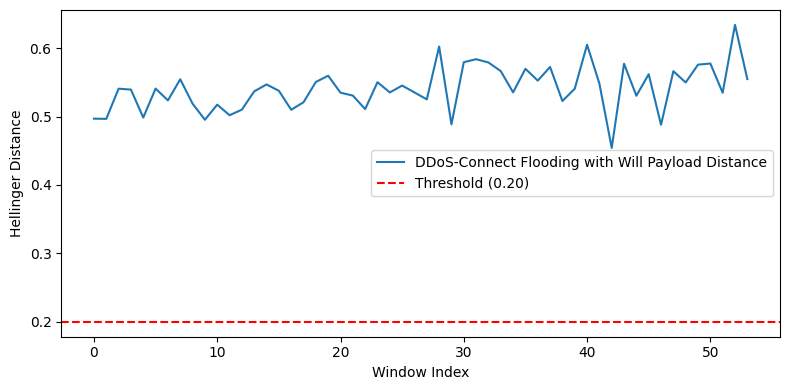

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(attack2_distances.values, label="DDoS-Connect Flooding with Will Payload Distance")
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold (0.20)")
#plt.title("CONNECT FLOODING WITH WILL PAYLOAD Detection")
plt.xlabel("Window Index")
plt.ylabel("Hellinger Distance")
plt.legend()
plt.tight_layout()

plt.savefig("DDOS-connect_WILLPAYLOAD_detection.png", dpi=300)
plt.savefig("DDOS-connect_WILLPAYLOAD_detection.eps", format='eps')

plt.show()

In [24]:
# Labels
normal_labels = np.zeros(len(normal_distances))
attack2_labels = np.ones(len(attack2_distances))

# Combine
all_distances = np.concatenate([normal_distances.values,
                                attack2_distances.values])

all_labels = np.concatenate([normal_labels,
                             attack2_labels])

# Predict using threshold
predictions = (all_distances > threshold).astype(int)

# Metrics
TP = np.sum((predictions == 1) & (all_labels == 1))
TN = np.sum((predictions == 0) & (all_labels == 0))
FP = np.sum((predictions == 1) & (all_labels == 0))
FN = np.sum((predictions == 0) & (all_labels == 1))

accuracy = (TP + TN) / len(all_labels)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("False Positive Rate:", fpr)


Accuracy: 0.9816487037576463
Recall: 1.0
False Positive Rate: 0.01864456939923054


In [25]:
#Attack3: DDOS-Delayed connect flooding
import pandas as pd
import numpy as np

attack3_path = "/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Delayed Connect Flooding/DDoS/CSV Files/Delay_DDoS_AD_1.csv"

event_types = [
    'Connect Command',
    'Connect Ack',
    'Publish Message',
    'Publish Ack',
    'Publish Release',
    'Publish Complete',
    'Ping Request',
    'Ping Response'
]

window_size = 5
chunk_size = 100000

attack3_window_counts = {}

for chunk in pd.read_csv(
        attack_path,
        usecols=['Protocol','Epoch Time','Message Type'],
        chunksize=chunk_size):

    # Keep only MQTT rows
    chunk = chunk[chunk['Protocol'] == 'MQTT']

    # Remove NaN message types
    chunk = chunk[chunk['Message Type'].notna()]

    # Convert Epoch Time
    chunk['Time'] = pd.to_numeric(chunk['Epoch Time'], errors='coerce')

    # Normalize time to start at 0 (important!)
    chunk['Time'] = chunk['Time'] - chunk['Time'].min()

    # Create 5-second windows
    chunk['window'] = (chunk['Time'] // window_size).astype(int)

    # Initialize windows
    for w in chunk['window'].unique():
        if w not in attack3_window_counts:
            attack3_window_counts[w] = {e:0 for e in event_types}

    # Count events
    grouped = chunk.groupby(['window','Message Type']).size()

    for (w, msg), count in grouped.items():
        if msg in event_types:
            attack3_window_counts[w][msg] += int(count)

print("Attack processing finished.")


Attack processing finished.


In [26]:
attack3_df = pd.DataFrame.from_dict(
    attack3_window_counts, orient='index'
).fillna(0)

print("Attack windows:", attack3_df.shape)
print(attack3_df.head())


Attack windows: (58, 8)
   Connect Command  Connect Ack  Publish Message  Publish Ack  \
0             1177            0               44           51   
1             1200            0               47           59   
2             1226            0               51           61   
3             1407            0               45           54   
4             1247            0               42           63   

   Publish Release  Publish Complete  Ping Request  Ping Response  
0               37                34             1              0  
1               21                28             1              0  
2               23                33             0              0  
3               18                29             0              0  
4               19                28             0              0  


In [27]:
attack3_prob = attack3_df.div(
    attack3_df.sum(axis=1), axis=0
).fillna(0)


In [28]:
def hellinger(p, q):
    return np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2)) / np.sqrt(2)

attack3_distances = attack3_prob.apply(
    lambda row: hellinger(row.values, baseline_profile.values),
    axis=1
)

print(attack3_distances.describe())

count    58.000000
mean      0.553159
std       0.039443
min       0.469413
25%       0.537322
50%       0.553946
75%       0.575437
max       0.712443
dtype: float64


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


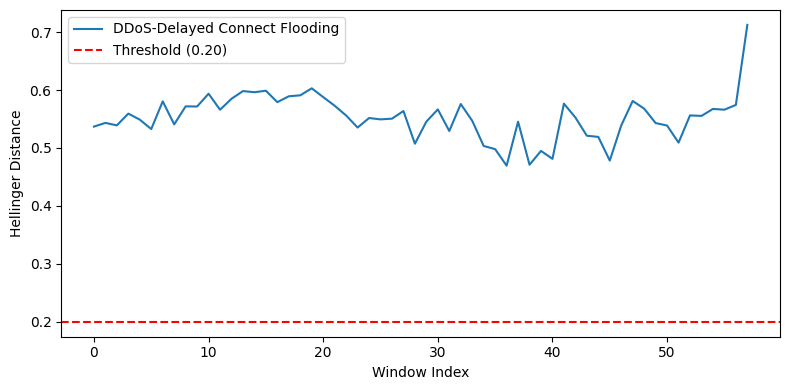

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(attack3_distances.values, label="DDoS-Delayed Connect Flooding")
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold (0.20)")
#plt.title("Delayed Connect flooding Detection")
plt.xlabel("Window Index")
plt.ylabel("Hellinger Distance")
plt.legend()
plt.tight_layout()

plt.savefig("DDOS-delayedconnect_flooding_detection.png", dpi=300)
plt.savefig("DDOS-delayedconnect_flooding_detection.eps", format='eps')

plt.show()

In [30]:
# Labels
normal_labels = np.zeros(len(normal_distances))
attack3_labels = np.ones(len(attack3_distances))

# Combine
all_distances = np.concatenate([normal_distances.values,
                                attack3_distances.values])

all_labels = np.concatenate([normal_labels,
                             attack3_labels])

# Predict using threshold
predictions = (all_distances > threshold).astype(int)

# Metrics
TP = np.sum((predictions == 1) & (all_labels == 1))
TN = np.sum((predictions == 0) & (all_labels == 0))
FP = np.sum((predictions == 1) & (all_labels == 0))
FN = np.sum((predictions == 0) & (all_labels == 1))

accuracy = (TP + TN) / len(all_labels)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("False Positive Rate:", fpr)


Accuracy: 0.9816700610997964
Recall: 1.0
False Positive Rate: 0.01864456939923054


In [31]:
#Attack4: DDOS-Invalid subscription flooding
import pandas as pd
import numpy as np

attack4_path = "/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Invalid Subscription Flooding/DDoS/CSV Files/Sub_DDoS_AD_1.csv"

event_types = [
    'Connect Command',
    'Connect Ack',
    'Publish Message',
    'Publish Ack',
    'Publish Release',
    'Publish Complete',
    'Ping Request',
    'Ping Response'
]

window_size = 5
chunk_size = 100000

attack4_window_counts = {}
for chunk in pd.read_csv(
        attack4_path,
        usecols=['Protocol','Epoch Time','Message Type'],
        chunksize=chunk_size):

    # Keep only MQTT rows
    chunk = chunk[chunk['Protocol'] == 'MQTT']

    # Remove NaN message types
    chunk = chunk[chunk['Message Type'].notna()]

    # Convert Epoch Time
    chunk['Time'] = pd.to_numeric(chunk['Epoch Time'], errors='coerce')

    # Normalize time to start at 0 (important!)
    chunk['Time'] = chunk['Time'] - chunk['Time'].min()

    # Create 5-second windows
    chunk['window'] = (chunk['Time'] // window_size).astype(int)

    # Initialize windows
    for w in chunk['window'].unique():
        if w not in attack4_window_counts:
            attack4_window_counts[w] = {e:0 for e in event_types}

    # Count events
    grouped = chunk.groupby(['window','Message Type']).size()

    for (w, msg), count in grouped.items():
        if msg in event_types:
            attack4_window_counts[w][msg] += int(count)

print("Attack processing finished.")


Attack processing finished.


In [32]:
attack4_df = pd.DataFrame.from_dict(
    attack4_window_counts, orient='index'
).fillna(0)

print("Attack windows:", attack4_df.shape)
print(attack4_df.head())


Attack windows: (157, 8)
   Connect Command  Connect Ack  Publish Message  Publish Ack  \
0              153            0               23           27   
1              153            0               24           28   
2              157            0               24           30   
3              173            0               24           25   
4              175            0               19           28   

   Publish Release  Publish Complete  Ping Request  Ping Response  
0               18                23             0              0  
1               14                19             0              0  
2               14                22             0              0  
3               15                21             0              0  
4               15                23             0              0  


In [33]:
attack4_prob = attack4_df.div(
    attack4_df.sum(axis=1), axis=0
).fillna(0)


In [34]:
def hellinger(p, q):
    return np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2)) / np.sqrt(2)

attack4_distances = attack4_prob.apply(
    lambda row: hellinger(row.values, baseline_profile.values),
    axis=1
)

print(attack4_distances.describe())

count    157.000000
mean       0.458080
std        0.017677
min        0.418686
25%        0.445693
50%        0.457564
75%        0.471193
max        0.503176
dtype: float64


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


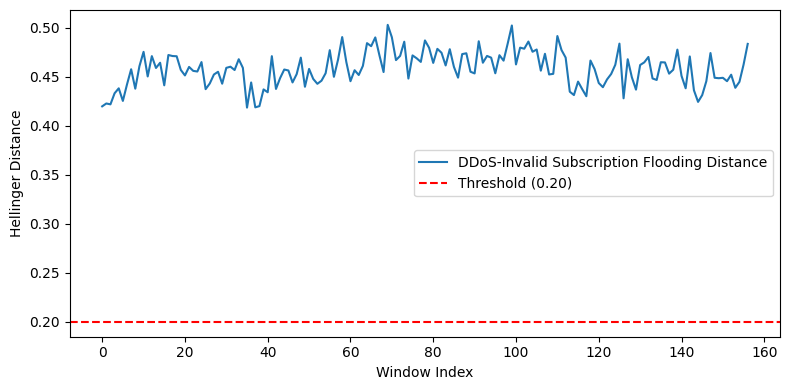

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(attack4_distances.values, label="DDoS-Invalid Subscription Flooding Distance")
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold (0.20)")
#plt.title("invalid subscription flooding Detection")
plt.xlabel("Window Index")
plt.ylabel("Hellinger Distance")
plt.legend()
plt.tight_layout()

plt.savefig("DDoS-invalidsub_flooding_detection.png", dpi=300)
plt.savefig("DDoS-invalidsub_flooding_detection.eps", format='eps')

plt.show()

In [36]:
# Labels
normal_labels = np.zeros(len(normal_distances))
attack4_labels = np.ones(len(attack4_distances))

# Combine
all_distances = np.concatenate([normal_distances.values,
                                attack4_distances.values])

all_labels = np.concatenate([normal_labels,
                             attack4_labels])

# Predict using threshold
predictions = (all_distances > threshold).astype(int)

# Metrics
TP = np.sum((predictions == 1) & (all_labels == 1))
TN = np.sum((predictions == 0) & (all_labels == 0))
FP = np.sum((predictions == 1) & (all_labels == 0))
FN = np.sum((predictions == 0) & (all_labels == 1))

accuracy = (TP + TN) / len(all_labels)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("False Positive Rate:", fpr)


Accuracy: 0.982183257918552
Recall: 1.0
False Positive Rate: 0.01864456939923054


In [37]:
from sklearn.metrics import roc_curve, auc

fpr_vals, tpr_vals, _ = roc_curve(all_labels, all_distances)
roc_auc = auc(fpr_vals, tpr_vals)

print("AUC:", roc_auc)


AUC: 0.9999528749130542


In [38]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Combine distances
all_distances = np.concatenate([
    normal_distances.values,
    attack4_distances.values
])

# Labels: 0 = normal, 1 = attack
all_labels = np.concatenate([
    np.zeros(len(normal_distances)),
    np.ones(len(attack4_distances))
])


In [39]:
fpr_vals, tpr_vals, thresholds = roc_curve(all_labels, all_distances)
roc_auc = auc(fpr_vals, tpr_vals)

print("AUC:", roc_auc)


AUC: 0.9999528749130542


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


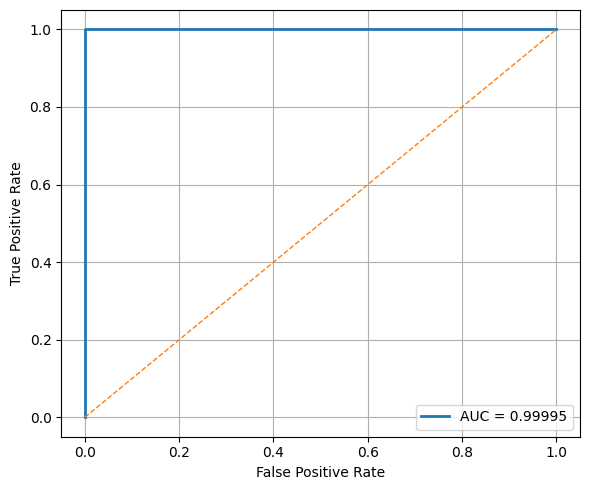

In [40]:
plt.figure(figsize=(6,5))

plt.plot(fpr_vals, tpr_vals, linewidth=2, label=f"AUC = {roc_auc:.5f}")
plt.plot([0,1], [0,1], linestyle='--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
#plt.title("ROC Curve for MQTT DDoS Detection")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("roc_curve.eps", format='eps')
plt.show()


In [41]:
import numpy as np

all_attack_distances = np.concatenate([
    attack1_distances.values,
    attack2_distances.values,
    attack3_distances.values,
    attack4_distances.values
])


In [42]:
overall_mean = np.mean(all_attack_distances)
overall_std  = np.std(all_attack_distances)

print("Overall Mean Distance:", overall_mean)
print("Overall Std:", overall_std)


Overall Mean Distance: 0.5054940018006795
Overall Std: 0.05441857647415873


In [43]:
print("Normal mean:", np.mean(normal_distances))
print("Basic mean:", np.mean(attack1_distances))
print("WILL mean:", np.mean(attack2_distances))
print("Delayed mean:", np.mean(attack3_distances))
print("Invalid mean:", np.mean(attack4_distances))


Normal mean: 0.0622827409685228
Basic mean: 0.5531585270176375
WILL mean: 0.5409546768533308
Delayed mean: 0.5531585270176375
Invalid mean: 0.45808023506176043


In [44]:

all_attack_distances = np.concatenate([
    attack1_distances.values,
    attack2_distances.values,
    attack3_distances.values,
    attack4_distances.values
])

print("Overall Attack Mean:", np.mean(all_attack_distances))
print("Overall Attack Std:", np.std(all_attack_distances))


Overall Attack Mean: 0.5054940018006795
Overall Attack Std: 0.05441857647415873


Combined AUC: 0.9999773741937295


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


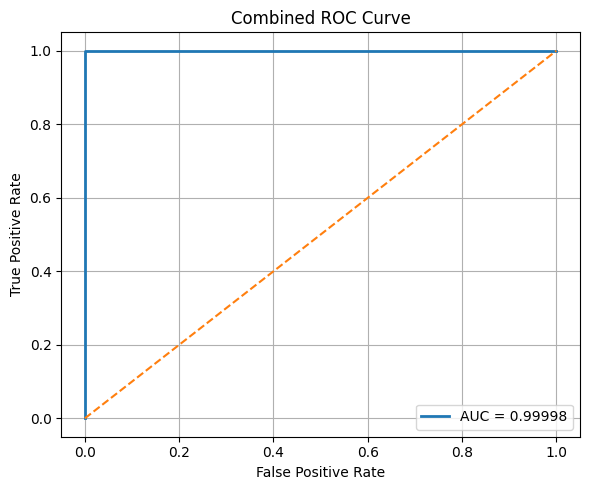

In [45]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

all_distances = np.concatenate([
    normal_distances.values,
    all_attack_distances
])

all_labels = np.concatenate([
    np.zeros(len(normal_distances)),
    np.ones(len(all_attack_distances))
])

fpr_vals, tpr_vals, _ = roc_curve(all_labels, all_distances)
roc_auc = auc(fpr_vals, tpr_vals)

print("Combined AUC:", roc_auc)

plt.figure(figsize=(6,5))
plt.plot(fpr_vals, tpr_vals, linewidth=2,
         label=f"AUC = {roc_auc:.5f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("combined_roc_curve.eps", format='eps')
plt.show()


In [46]:
#Attack5: DOS-Basic connect flooding
import pandas as pd
import numpy as np

attack11_path = "/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Basic Connect Flooding/DoS/CSV Files/BF1_DoS_AD_12.csv"

event_types = [
    'Connect Command',
    'Connect Ack',
    'Publish Message',
    'Publish Ack',
    'Publish Release',
    'Publish Complete',
    'Ping Request',
    'Ping Response'
]

window_size = 5
chunk_size = 100000

attack11_window_counts = {}

for chunk in pd.read_csv(
        attack11_path,
        usecols=['Protocol','Epoch Time','Message Type'],
        chunksize=chunk_size):

    # Keep only MQTT rows
    chunk = chunk[chunk['Protocol'] == 'MQTT']

    # Remove NaN message types
    chunk = chunk[chunk['Message Type'].notna()]

    # Convert Epoch Time
    chunk['Time'] = pd.to_numeric(chunk['Epoch Time'], errors='coerce')

    # Normalize time to start at 0 (important!)
    chunk['Time'] = chunk['Time'] - chunk['Time'].min()

    # Create 5-second windows
    chunk['window'] = (chunk['Time'] // window_size).astype(int)

    # Initialize windows
    for w in chunk['window'].unique():
        if w not in attack11_window_counts:
            attack11_window_counts[w] = {e:0 for e in event_types}

    # Count events
    grouped = chunk.groupby(['window','Message Type']).size()

    for (w, msg), count in grouped.items():
        if msg in event_types:
            attack11_window_counts[w][msg] += int(count)

print("Attack processing finished.")


Attack processing finished.


In [47]:
attack11_df = pd.DataFrame.from_dict(
    attack11_window_counts, orient='index'
).fillna(0)

print("Attack windows:", attack11_df.shape)
print(attack11_df.head())

Attack windows: (73, 8)
   Connect Command  Connect Ack  Publish Message  Publish Ack  \
0             1328            0               35           46   
1              671            0               51           55   
2              773            0               37           52   
3              779            0               47           43   
4              674            0               40           45   

   Publish Release  Publish Complete  Ping Request  Ping Response  
0               14                19             0              0  
1               15                23             0              0  
2               16                22             0              0  
3               19                25             1              0  
4               22                29             0              0  


In [48]:
attack11_prob = attack11_df.div(
    attack11_df.sum(axis=1), axis=0
).fillna(0)

In [49]:

def hellinger(p, q):
    return np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2)) / np.sqrt(2)

attack11_distances = attack11_prob.apply(
    lambda row: hellinger(row.values, baseline_profile.values),
    axis=1
)

print(attack11_distances.describe())

count    73.000000
mean      0.517013
std       0.019716
min       0.476125
25%       0.505077
50%       0.514643
75%       0.525999
max       0.572207
dtype: float64


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


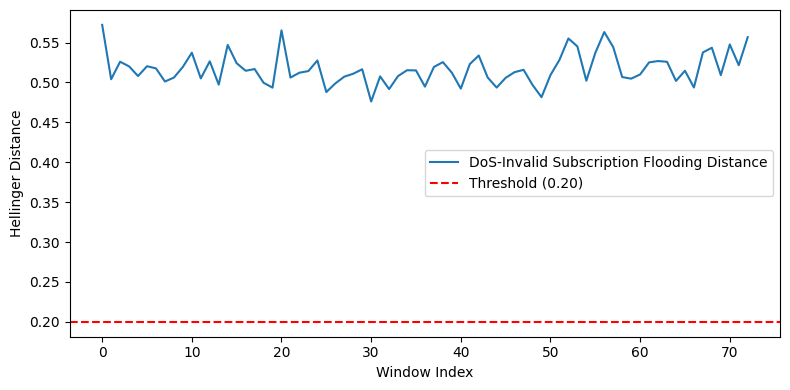

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(attack11_distances.values, label="DoS-Invalid Subscription Flooding Distance")
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold (0.20)")
#plt.title("invalid subscription flooding Detection")
plt.xlabel("Window Index")
plt.ylabel("Hellinger Distance")
plt.legend()
plt.tight_layout()

plt.savefig("DoS-invalidsub_flooding_detection.png", dpi=300)
plt.savefig("DoS-invalidsub_flooding_detection.eps", format='eps')

plt.show()

In [51]:
# Labels
normal_labels = np.zeros(len(normal_distances))
attack11_labels = np.ones(len(attack11_distances))

# Combine
all_distances = np.concatenate([normal_distances.values,
                                attack11_distances.values])

all_labels = np.concatenate([normal_labels,
                             attack11_labels])

# Predict using threshold
predictions = (all_distances > threshold).astype(int)

# Metrics
TP = np.sum((predictions == 1) & (all_labels == 1))
TN = np.sum((predictions == 0) & (all_labels == 0))
FP = np.sum((predictions == 1) & (all_labels == 0))
FN = np.sum((predictions == 0) & (all_labels == 1))

accuracy = (TP + TN) / len(all_labels)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("False Positive Rate:", fpr)


Accuracy: 0.9817497103128621
Recall: 1.0
False Positive Rate: 0.01864456939923054


In [52]:
#Attack6: DOS-WILL payload connect flooding
import pandas as pd
import numpy as np

attack22_path = "/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Connect Flooding with WILL payload/DoS/CSV Files/WILL_DoS_AD_11.csv"

event_types = [
    'Connect Command',
    'Connect Ack',
    'Publish Message',
    'Publish Ack',
    'Publish Release',
    'Publish Complete',
    'Ping Request',
    'Ping Response'
]

window_size = 5
chunk_size = 100000

attack22_window_counts = {}

for chunk in pd.read_csv(
        attack11_path,
        usecols=['Protocol','Epoch Time','Message Type'],
        chunksize=chunk_size):

    # Keep only MQTT rows
    chunk = chunk[chunk['Protocol'] == 'MQTT']

    # Remove NaN message types
    chunk = chunk[chunk['Message Type'].notna()]

    # Convert Epoch Time
    chunk['Time'] = pd.to_numeric(chunk['Epoch Time'], errors='coerce')

    # Normalize time to start at 0 (important!)
    chunk['Time'] = chunk['Time'] - chunk['Time'].min()

    # Create 5-second windows
    chunk['window'] = (chunk['Time'] // window_size).astype(int)

    # Initialize windows
    for w in chunk['window'].unique():
        if w not in attack22_window_counts:
            attack22_window_counts[w] = {e:0 for e in event_types}

    # Count events
    grouped = chunk.groupby(['window','Message Type']).size()

    for (w, msg), count in grouped.items():
        if msg in event_types:
            attack22_window_counts[w][msg] += int(count)

print("Attack processing finished.")

Attack processing finished.


In [53]:
attack22_df = pd.DataFrame.from_dict(
    attack22_window_counts, orient='index'
).fillna(0)

print("Attack windows:", attack22_df.shape)
print(attack22_df.head())

Attack windows: (73, 8)
   Connect Command  Connect Ack  Publish Message  Publish Ack  \
0             1328            0               35           46   
1              671            0               51           55   
2              773            0               37           52   
3              779            0               47           43   
4              674            0               40           45   

   Publish Release  Publish Complete  Ping Request  Ping Response  
0               14                19             0              0  
1               15                23             0              0  
2               16                22             0              0  
3               19                25             1              0  
4               22                29             0              0  


In [54]:
attack22_prob = attack22_df.div(
    attack22_df.sum(axis=1), axis=0
).fillna(0)

def hellinger(p, q):
    return np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2)) / np.sqrt(2)

attack22_distances = attack22_prob.apply(
    lambda row: hellinger(row.values, baseline_profile.values),
    axis=1
)

print(attack22_distances.describe())

count    73.000000
mean      0.517013
std       0.019716
min       0.476125
25%       0.505077
50%       0.514643
75%       0.525999
max       0.572207
dtype: float64


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


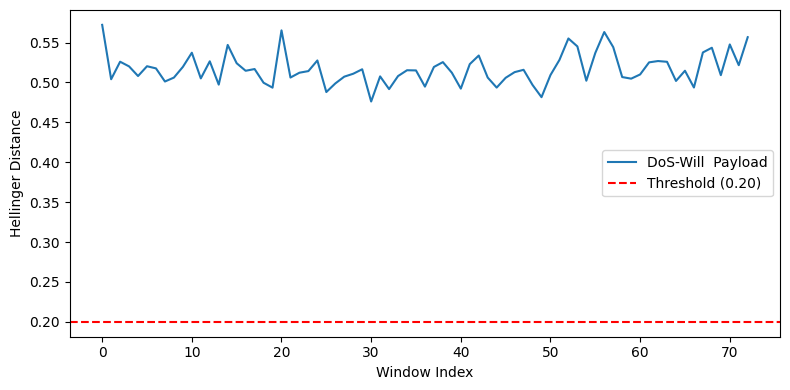

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(attack22_distances.values, label="DoS-Will  Payload")
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold (0.20)")
#plt.title("invalid subscription flooding Detection")
plt.xlabel("Window Index")
plt.ylabel("Hellinger Distance")
plt.legend()
plt.tight_layout()

plt.savefig("DoS-willpayload.png", dpi=300)
plt.savefig("DoS-willpayload.eps", format='eps')

plt.show()

In [56]:
# Labels
normal_labels = np.zeros(len(normal_distances))
attack22_labels = np.ones(len(attack22_distances))

# Combine
all_distances = np.concatenate([normal_distances.values,
                                attack22_distances.values])

all_labels = np.concatenate([normal_labels,
                             attack22_labels])

# Predict using threshold
predictions = (all_distances > threshold).astype(int)

# Metrics
TP = np.sum((predictions == 1) & (all_labels == 1))
TN = np.sum((predictions == 0) & (all_labels == 0))
FP = np.sum((predictions == 1) & (all_labels == 0))
FN = np.sum((predictions == 0) & (all_labels == 1))

accuracy = (TP + TN) / len(all_labels)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("False Positive Rate:", fpr)

Accuracy: 0.9817497103128621
Recall: 1.0
False Positive Rate: 0.01864456939923054


In [57]:
#Attack7: DOS-WILL payload connect flooding
import pandas as pd
import numpy as np

attack33_path = "/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Delayed Connect Flooding/DoS/CSV Files/Delay_DoS_AD_11.csv"

event_types = [
    'Connect Command',
    'Connect Ack',
    'Publish Message',
    'Publish Ack',
    'Publish Release',
    'Publish Complete',
    'Ping Request',
    'Ping Response'
]

window_size = 5
chunk_size = 100000

attack33_window_counts = {}

for chunk in pd.read_csv(
        attack33_path,
        usecols=['Protocol','Epoch Time','Message Type'],
        chunksize=chunk_size):

    # Keep only MQTT rows
    chunk = chunk[chunk['Protocol'] == 'MQTT']

    # Remove NaN message types
    chunk = chunk[chunk['Message Type'].notna()]

    # Convert Epoch Time
    chunk['Time'] = pd.to_numeric(chunk['Epoch Time'], errors='coerce')

    # Normalize time to start at 0 (important!)
    chunk['Time'] = chunk['Time'] - chunk['Time'].min()

    # Create 5-second windows
    chunk['window'] = (chunk['Time'] // window_size).astype(int)

    # Initialize windows
    for w in chunk['window'].unique():
        if w not in attack33_window_counts:
            attack33_window_counts[w] = {e:0 for e in event_types}

    # Count events
    grouped = chunk.groupby(['window','Message Type']).size()

    for (w, msg), count in grouped.items():
        if msg in event_types:
            attack33_window_counts[w][msg] += int(count)

print("Attack processing finished.")

Attack processing finished.


In [58]:
attack33_df = pd.DataFrame.from_dict(
    attack33_window_counts, orient='index'
).fillna(0)

print("Attack windows:", attack33_df.shape)
print(attack33_df.head())

Attack windows: (143, 8)
   Connect Command  Connect Ack  Publish Message  Publish Ack  \
0              289            0               40           47   
1              286            0               37           38   
2              283            0               35           52   
3              289            0               33           33   
4              289            0               41           42   

   Publish Release  Publish Complete  Ping Request  Ping Response  
0               18                25             0              0  
1               19                26             1              0  
2               18                25             0              0  
3               19                26             0              0  
4               31                29             0              0  


In [59]:
attack33_prob = attack33_df.div(
    attack33_df.sum(axis=1), axis=0
).fillna(0)

def hellinger(p, q):
    return np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2)) / np.sqrt(2)

attack33_distances = attack33_prob.apply(
    lambda row: hellinger(row.values, baseline_profile.values),
    axis=1
)

print(attack33_distances.describe())

count    143.000000
mean       0.455493
std        0.010427
min        0.410516
25%        0.450071
50%        0.455761
75%        0.461428
max        0.482152
dtype: float64


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


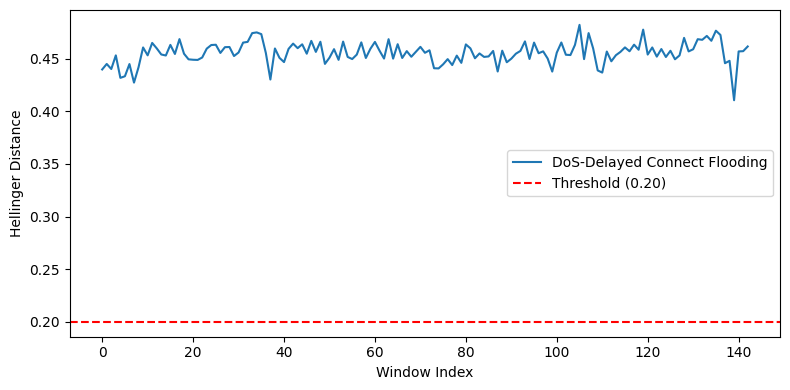

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(attack33_distances.values, label="DoS-Delayed Connect Flooding")
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold (0.20)")
#plt.title("invalid subscription flooding Detection")
plt.xlabel("Window Index")
plt.ylabel("Hellinger Distance")
plt.legend()
plt.tight_layout()

plt.savefig("DoS-delayedcf.png", dpi=300)
plt.savefig("DoS-delayedcf.eps", format='eps')

plt.show()

In [61]:
# Labels
normal_labels = np.zeros(len(normal_distances))
attack33_labels = np.ones(len(attack33_distances))

# Combine
all_distances = np.concatenate([normal_distances.values,
                                attack33_distances.values])

all_labels = np.concatenate([normal_labels,
                             attack33_labels])

# Predict using threshold
predictions = (all_distances > threshold).astype(int)

# Metrics
TP = np.sum((predictions == 1) & (all_labels == 1))
TN = np.sum((predictions == 0) & (all_labels == 0))
FP = np.sum((predictions == 1) & (all_labels == 0))
FN = np.sum((predictions == 0) & (all_labels == 1))

accuracy = (TP + TN) / len(all_labels)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("False Positive Rate:", fpr)

Accuracy: 0.9821124361158433
Recall: 1.0
False Positive Rate: 0.01864456939923054


In [62]:
#Attack8: DOS-Invalid subscription
import pandas as pd
import numpy as np

attack44_path = "/kaggle/input/dosddos-mqtt-iot/DoS-DDoS-MQTT-IoT_Dataset/Invalid Subscription Flooding/DoS/CSV Files/Sub_DoS_AD_11.csv"

event_types = [
    'Connect Command',
    'Connect Ack',
    'Publish Message',
    'Publish Ack',
    'Publish Release',
    'Publish Complete',
    'Ping Request',
    'Ping Response'
]
window_size = 5
chunk_size = 100000

attack44_window_counts = {}

for chunk in pd.read_csv(
        attack44_path,
        usecols=['Protocol','Epoch Time','Message Type'],
        chunksize=chunk_size):

    # Keep only MQTT rows
    chunk = chunk[chunk['Protocol'] == 'MQTT']

    # Remove NaN message types
    chunk = chunk[chunk['Message Type'].notna()]

    # Convert Epoch Time
    chunk['Time'] = pd.to_numeric(chunk['Epoch Time'], errors='coerce')

    # Normalize time to start at 0 (important!)
    chunk['Time'] = chunk['Time'] - chunk['Time'].min()

    # Create 5-second windows
    chunk['window'] = (chunk['Time'] // window_size).astype(int)

    # Initialize windows
    for w in chunk['window'].unique():
        if w not in attack44_window_counts:
            attack44_window_counts[w] = {e:0 for e in event_types}

    # Count events
    grouped = chunk.groupby(['window','Message Type']).size()

    for (w, msg), count in grouped.items():
        if msg in event_types:
            attack44_window_counts[w][msg] += int(count)

print("Attack processing finished.")

Attack processing finished.


In [63]:
attack44_df = pd.DataFrame.from_dict(
    attack44_window_counts, orient='index'
).fillna(0)

print("Attack windows:", attack44_df.shape)
print(attack44_df.head())

Attack windows: (74, 8)
   Connect Command  Connect Ack  Publish Message  Publish Ack  \
0              593            0               24            0   
1              480            0               16            0   
2              498            0               12            2   
3              533            0               17            5   
4              527            0               14            9   

   Publish Release  Publish Complete  Ping Request  Ping Response  
0                0                 0             2              0  
1                4                 0             0              0  
2                3                 3             1              0  
3                3                 3             0              0  
4                4                 0             0              0  


In [64]:
attack44_prob = attack44_df.div(
    attack44_df.sum(axis=1), axis=0
).fillna(0)

def hellinger(p, q):
    return np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2)) / np.sqrt(2)

attack44_distances = attack44_prob.apply(
    lambda row: hellinger(row.values, baseline_profile.values),
    axis=1
)

print(attack44_distances.describe())

count    74.000000
mean      0.643128
std       0.031591
min       0.531768
25%       0.625840
50%       0.645790
75%       0.662254
max       0.712241
dtype: float64


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


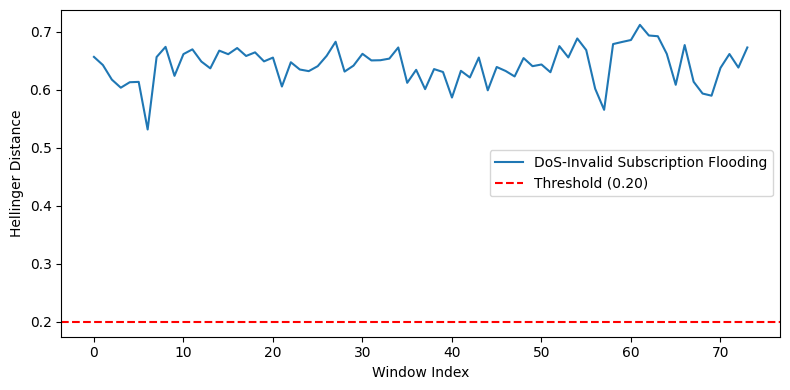

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(attack44_distances.values, label="DoS-Invalid Subscription Flooding")
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold (0.20)")
#plt.title("invalid subscription flooding Detection")
plt.xlabel("Window Index")
plt.ylabel("Hellinger Distance")
plt.legend()
plt.tight_layout()

plt.savefig("DoS-inval.png", dpi=300)
plt.savefig("DoS-inval.eps", format='eps')

plt.show()

In [66]:
# Labels
normal_labels = np.zeros(len(normal_distances))
attack44_labels = np.ones(len(attack44_distances))

# Combine
all_distances = np.concatenate([normal_distances.values,
                                attack44_distances.values])

all_labels = np.concatenate([normal_labels,
                             attack44_labels])

# Predict using threshold
predictions = (all_distances > threshold).astype(int)

# Metrics
TP = np.sum((predictions == 1) & (all_labels == 1))
TN = np.sum((predictions == 0) & (all_labels == 0))
FP = np.sum((predictions == 1) & (all_labels == 0))
FN = np.sum((predictions == 0) & (all_labels == 1))

accuracy = (TP + TN) / len(all_labels)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("False Positive Rate:", fpr)

Accuracy: 0.9817549956559514
Recall: 1.0
False Positive Rate: 0.01864456939923054


In [67]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

def evaluate_attack(normal_distances, attack_distances, threshold):
    
    # Labels
    y_true = np.concatenate([
        np.zeros(len(normal_distances)),      # normal = 0
        np.ones(len(attack_distances))        # attack = 1
    ])
    
    # Scores
    scores = np.concatenate([
        normal_distances,
        attack_distances
    ])
    
    # Predictions using threshold
    y_pred = (scores > threshold).astype(int)
    
    # Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn)
    
    return acc, prec, rec, fpr


In [68]:
results = {}

attack_dict = {
    "BF_DDoS": attack1_distances,
    "BF_DoS": attack11_distances,
    "Delay_DDoS": attack3_distances,
    "Delay_DoS": attack33_distances,
    "Sub_DDoS": attack4_distances,
    "Sub_DoS": attack44_distances,
    "Will_DDoS": attack2_distances,
    "Will_DoS": attack22_distances
}

for name, distances in attack_dict.items():
    acc, prec, rec, fpr = evaluate_attack(normal_distances, distances, threshold)
    
    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "FPR": round(fpr, 4)
    }

results_df = pd.DataFrame(results).T
print(results_df)


            Accuracy  Precision  Recall     FPR
BF_DDoS       0.9817     0.4793     1.0  0.0186
BF_DoS        0.9817     0.5368     1.0  0.0186
Delay_DDoS    0.9817     0.4793     1.0  0.0186
Delay_DoS     0.9821     0.6942     1.0  0.0186
Sub_DDoS      0.9822     0.7136     1.0  0.0186
Sub_DoS       0.9818     0.5401     1.0  0.0186
Will_DDoS     0.9816     0.4615     1.0  0.0186
Will_DoS      0.9817     0.5368     1.0  0.0186


In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc(normal_distances, attack_distances, attack_name):
    
    y_true = np.concatenate([
        np.zeros(len(normal_distances)),
        np.ones(len(attack_distances))
    ])
    
    scores = np.concatenate([
        normal_distances,
        attack_distances
    ])
    
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {attack_name}")
    plt.legend()
    plt.grid()
    plt.show()
    
    return roc_auc


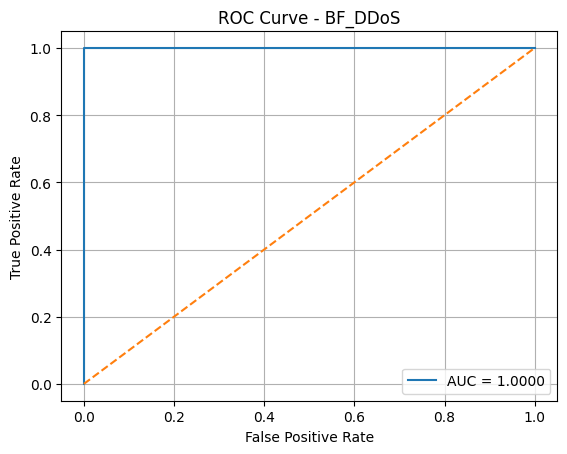

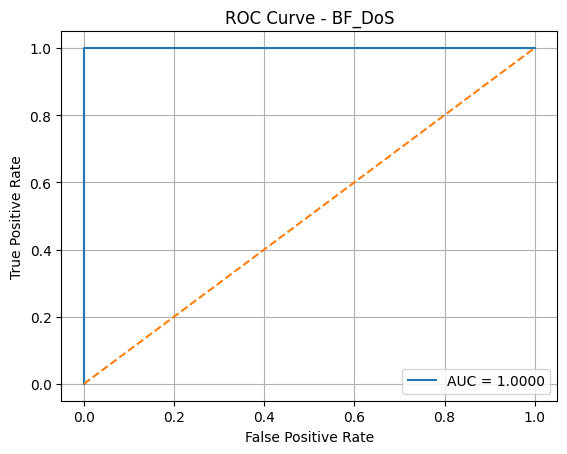

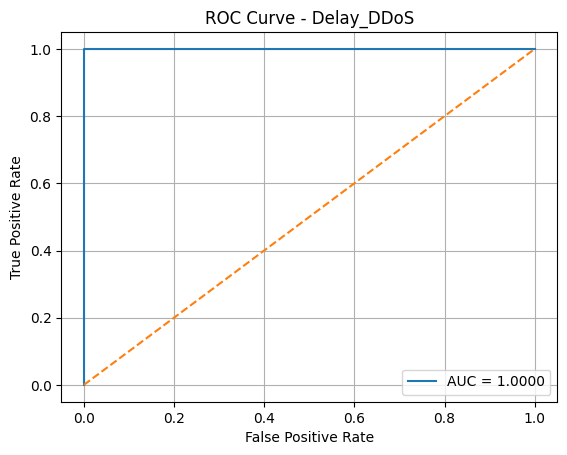

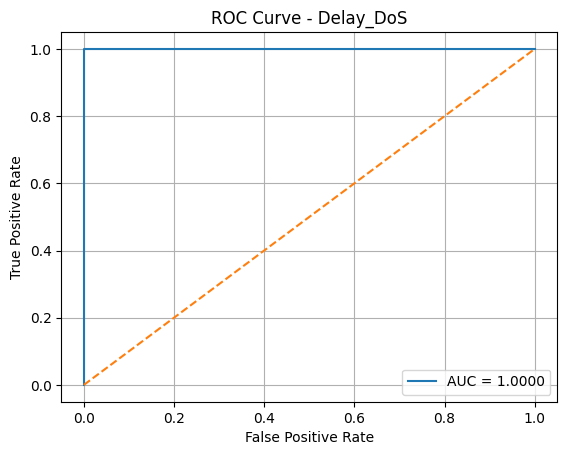

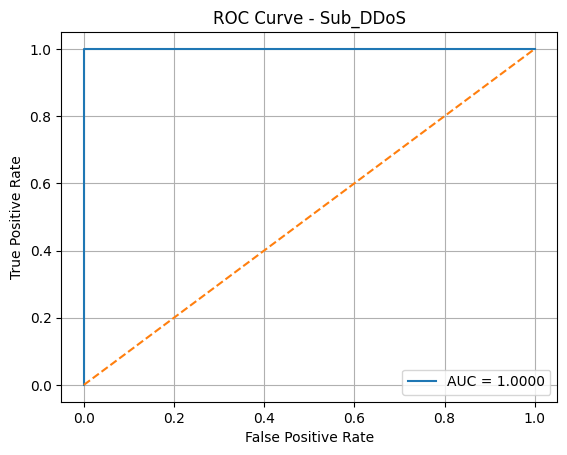

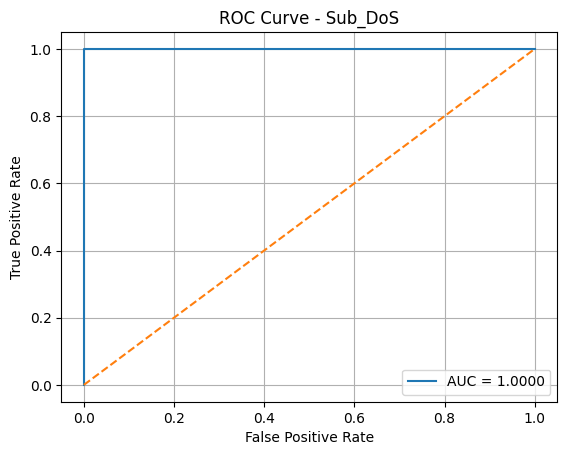

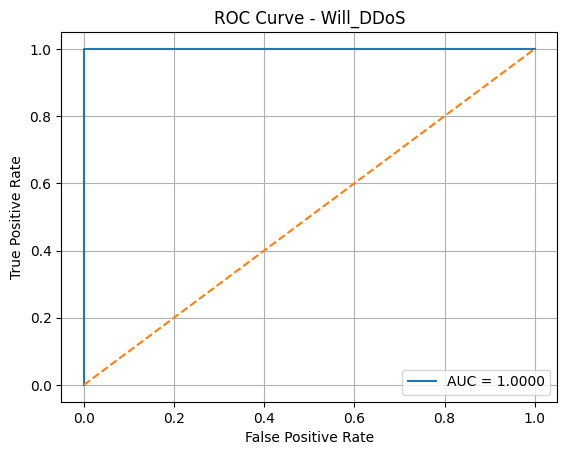

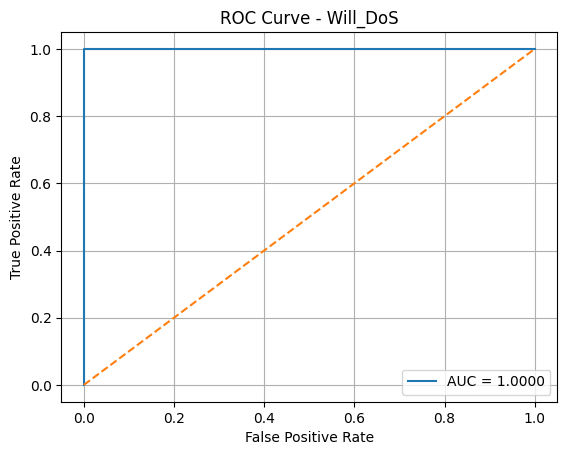

AUC Results:
{'BF_DDoS': np.float64(1.0), 'BF_DoS': np.float64(1.0), 'Delay_DDoS': np.float64(1.0), 'Delay_DoS': np.float64(1.0), 'Sub_DDoS': np.float64(1.0), 'Sub_DoS': np.float64(1.0), 'Will_DDoS': np.float64(1.0), 'Will_DoS': np.float64(1.0)}


In [70]:
auc_results = {}

attack_dict = {
    "BF_DDoS": attack1_distances,
    "BF_DoS": attack11_distances,
    "Delay_DDoS": attack3_distances,
    "Delay_DoS": attack33_distances,
    "Sub_DDoS": attack4_distances,
    "Sub_DoS": attack44_distances,
    "Will_DDoS": attack2_distances,
    "Will_DoS": attack22_distances
}

for name, dist in attack_dict.items():
    auc_value = plot_roc(normal_distances, dist, name)
    auc_results[name] = round(auc_value,4)

print("AUC Results:")
print(auc_results)


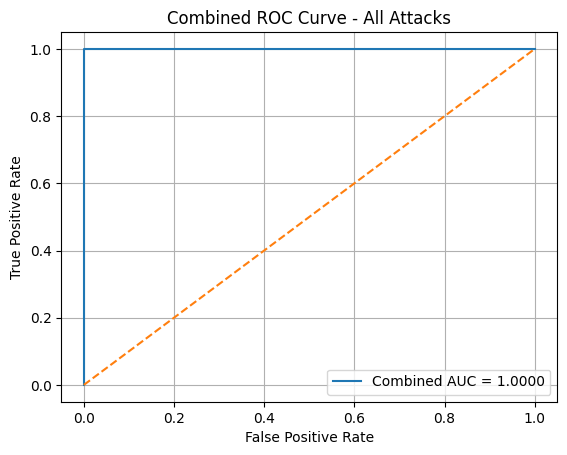

Combined AUC: 0.9999854171759933


In [71]:
all_attacks = np.concatenate(list(attack_dict.values()))

y_true = np.concatenate([
    np.zeros(len(normal_distances)),
    np.ones(len(all_attacks))
])

scores = np.concatenate([
    normal_distances,
    all_attacks
])

fpr, tpr, _ = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Combined AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curve - All Attacks")
plt.legend()
plt.grid()
plt.show()

print("Combined AUC:", roc_auc)
